
# Part 1.3 — Incomplete jump-diffusion market and the minimal entropy martingale measure

**Thesis reference:** Chapter 4 (exponential utility and minimal entropy), Chapter 7 — Experiment 3.

A Merton (1976) jump-diffusion model has two independent sources of randomness (a Brownian motion and a compound Poisson jump process) but only one tradable risky asset: the market is genuinely incomplete, and the family of equivalent martingale measures $\mathcal{M}_e(S)$ is infinite-dimensional. This notebook works within a tractable one-parameter Esscher/Girsanov sub-family $\{Q_\beta\}_{\beta \in \mathbb{R}}$ (Girsanov shift of the Brownian motion, combined with an exponential tilt of the jump-size distribution, with the Girsanov shift $\theta(\beta)$ determined by the martingale condition), rich enough to contain the minimal entropy martingale measure -- the dual optimizer identified by Chapter 4's theory for exponential utility.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from optiport.continuous.jump_diffusion import MertonJumpDiffusionMarket
from optiport.utility import ExponentialUtility

plt.rcParams["figure.dpi"] = 110

market = MertonJumpDiffusionMarket(
    mu=0.10, sigma=0.15, r=0.02, lam=0.8, jump_mean=-0.05, jump_std=0.10,
)
T, S0 = 1.0, 100.0



## 1. Why this market is incomplete: jump risk is not spanned

The histogram below compares simulated terminal log-returns of the jump-diffusion model to a pure-diffusion model with the same mean and variance. The extra mass in the left tail comes from the (negatively skewed, `jump_mean < 0`) jump component -- a source of risk that a single continuously-traded risky asset cannot hedge away, which is exactly why $|\mathcal{M}_e(S)| > 1$ here.


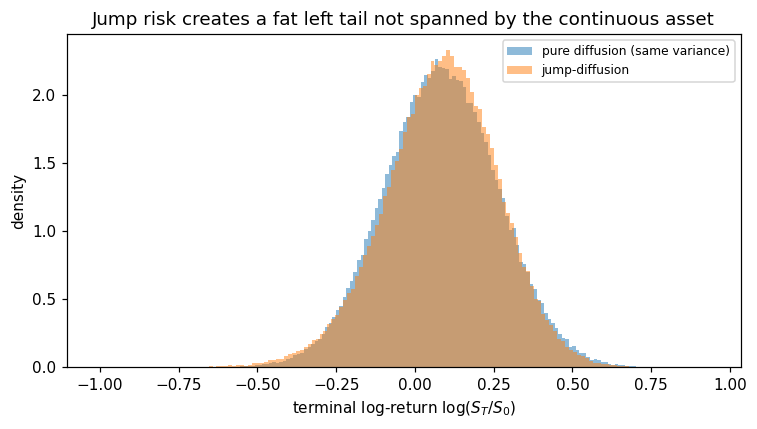

In [2]:

rng = np.random.default_rng(0)
prim = market.simulate_primitives(200_000, T, seed=0)
S_T_jump = market.terminal_price(S0, T, prim)
log_ret_jump = np.log(S_T_jump / S0)

# Pure-diffusion counterfactual with the same total variance (diffusion + jump variance)
total_var = market.sigma**2 * T + market.lam * T * (market.jump_std**2 + market.jump_mean**2)
sigma_eff = np.sqrt(total_var)
log_ret_diffusion = rng.normal((market.mu - 0.5*sigma_eff**2)*T, sigma_eff*np.sqrt(T), 200_000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_ret_diffusion, bins=150, density=True, alpha=0.5, label="pure diffusion (same variance)")
ax.hist(log_ret_jump, bins=150, density=True, alpha=0.5, label="jump-diffusion")
ax.set_xlabel(r"terminal log-return $\log(S_T/S_0)$")
ax.set_ylabel("density")
ax.legend(fontsize=8)
ax.set_title("Jump risk creates a fat left tail not spanned by the continuous asset")
fig.tight_layout()
plt.savefig("fig_01_jump_tail.png", bbox_inches="tight")
plt.show()



## 2. The Esscher/Girsanov family and the minimal entropy martingale measure

For each $\beta$, $\theta(\beta)$ is chosen so that $Q_\beta \in \mathcal{M}_e(S)$ (the martingale condition of Chapter 4's FTAP), giving a genuine one-parameter curve inside the infinite-dimensional set of equivalent martingale measures. We compute the relative entropy $D(Q_\beta \,\|\, P)$ along this curve and locate its minimiser $\beta^*$.


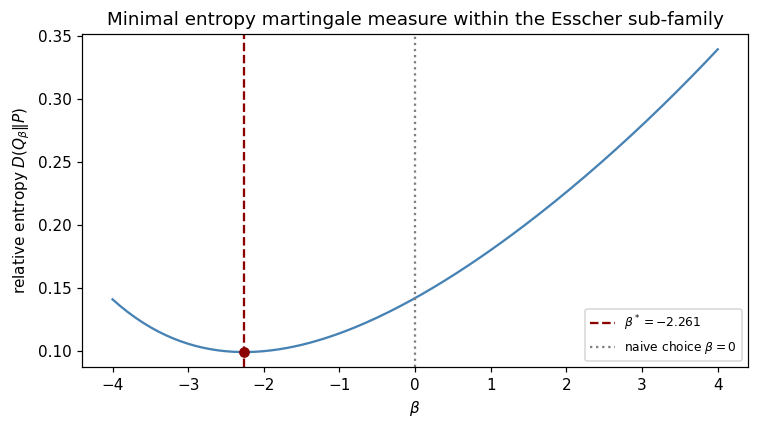

beta* = -2.2609, D(Q_beta*||P) = 0.09945, D(Q_0||P) = 0.14222


In [3]:

beta_grid = np.linspace(-4, 4, 161)
entropy = np.array([market.relative_entropy_closed_form(T, b) for b in beta_grid])
beta_star = market.minimal_entropy_beta(T)
entropy_star = market.relative_entropy_closed_form(T, beta_star)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(beta_grid, entropy, color="steelblue")
ax.axvline(beta_star, color="darkred", linestyle="--", label=fr"$\beta^*={beta_star:.3f}$")
ax.axvline(0.0, color="gray", linestyle=":", label=r"naive choice $\beta=0$")
ax.scatter([beta_star], [entropy_star], color="darkred", zorder=5)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"relative entropy $D(Q_\beta \| P)$")
ax.set_title("Minimal entropy martingale measure within the Esscher sub-family")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("fig_02_entropy_vs_beta.png", bbox_inches="tight")
plt.show()

print(f"beta* = {beta_star:.4f}, D(Q_beta*||P) = {entropy_star:.5f}, D(Q_0||P) = {market.relative_entropy_closed_form(T,0.0):.5f}")



As expected for a market with an asymmetric (negatively skewed) jump distribution, $\beta^* \neq 0$: the "naive" choice $\beta=0$ (shift only the Brownian motion, leave the jump distribution untilted) is *not* the minimal entropy measure, and is strictly farther from $P$ than $Q_{\beta^*}$.



## 3. Validating the martingale condition across the whole family

Every $Q_\beta$ in the family, not only $Q_{\beta^*}$, must satisfy the martingale condition $E^P[Z_T^\beta \cdot S_T] = S_0 e^{rT}$. We check this by Monte Carlo across the same grid of $\beta$ used above.


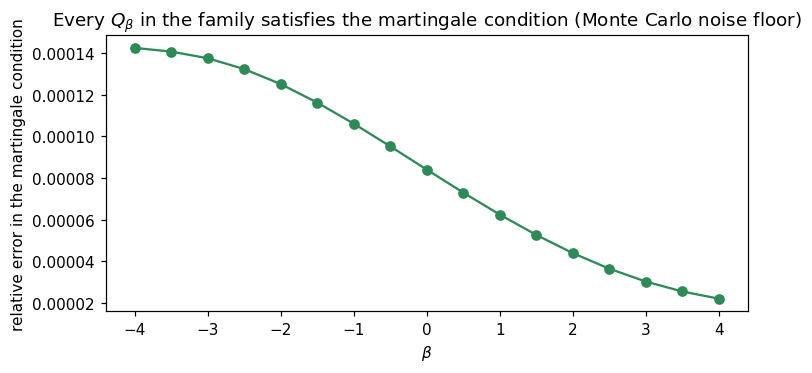

max relative error over the grid: 1.43e-04


In [4]:

prim_big = market.simulate_primitives(3_000_000, T, seed=5)
S_T = market.terminal_price(S0, T, prim_big)
target = S0 * np.exp(market.r * T)

check_betas = np.linspace(-4, 4, 17)
rel_errors = []
for b in check_betas:
    Z_T = market.radon_nikodym_Qbeta(T, b, prim_big)
    rel_errors.append(abs(np.mean(Z_T * S_T) - target) / target)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(check_betas, rel_errors, "-o", color="seagreen")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("relative error in the martingale condition")
ax.set_title("Every $Q_\\beta$ in the family satisfies the martingale condition (Monte Carlo noise floor)")
fig.tight_layout()
plt.savefig("fig_03_martingale_condition_check.png", bbox_inches="tight")
plt.show()
print(f"max relative error over the grid: {max(rel_errors):.2e}")



## 4. Cross-check: the exponential-utility dual objective is minimised at the same $\beta^*$

For exponential utility, Chapter 4 shows the dual objective $E^P[\tilde V(y H_T)]$ is, for any fixed $y$, an affine, increasing function of the relative entropy $D(Q_\beta\|P)$ alone -- so minimising the dual objective over $\beta$ must recover exactly the same $\beta^*$ found above by minimising the entropy directly. This is checked here by Monte Carlo, as an independent confirmation of the closed-form derivation.


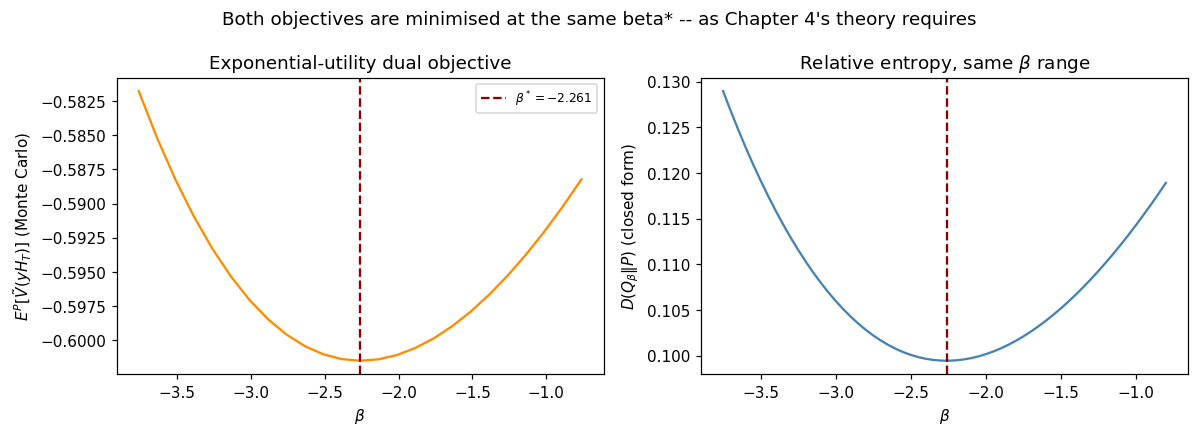

argmin of Monte Carlo dual objective: -2.261  vs.  beta* (entropy): -2.261


In [5]:

gamma, y_fixed = 1.5, 1.0
grid2 = np.linspace(beta_star - 1.5, beta_star + 1.5, 25)
dual_obj = [market.dual_objective_exponential_mc(T, b, y_fixed, gamma, prim_big) for b in grid2]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(grid2, dual_obj, color="darkorange")
axes[0].axvline(beta_star, color="darkred", linestyle="--", label=fr"$\beta^*={beta_star:.3f}$")
axes[0].set_xlabel(r"$\beta$"); axes[0].set_ylabel(r"$E^P[\tilde V(y H_T)]$ (Monte Carlo)")
axes[0].set_title("Exponential-utility dual objective"); axes[0].legend(fontsize=8)

axes[1].plot(beta_grid[(beta_grid>=grid2.min())&(beta_grid<=grid2.max())],
             entropy[(beta_grid>=grid2.min())&(beta_grid<=grid2.max())], color="steelblue")
axes[1].axvline(beta_star, color="darkred", linestyle="--")
axes[1].set_xlabel(r"$\beta$"); axes[1].set_ylabel(r"$D(Q_\beta\|P)$ (closed form)")
axes[1].set_title("Relative entropy, same $\\beta$ range")

fig.suptitle("Both objectives are minimised at the same beta* -- as Chapter 4's theory requires")
fig.tight_layout()
plt.savefig("fig_04_dual_objective_vs_entropy.png", bbox_inches="tight")
plt.show()

argmin_dual = grid2[int(np.argmin(dual_obj))]
print(f"argmin of Monte Carlo dual objective: {argmin_dual:.3f}  vs.  beta* (entropy): {beta_star:.3f}")



## Conclusion

This notebook confirms, in a genuinely incomplete market, the exponential-utility specialisation of the duality theorem of Chapter 4: within the Esscher sub-family, the martingale condition holds throughout (Section 3), the relative entropy is minimised at a non-trivial $\beta^* \neq 0$ (Section 2), and the exponential-utility dual objective is independently minimised at the same $\beta^*$ (Section 4) -- exactly the identification of the dual optimizer as the minimal entropy martingale measure. The results of this notebook replace the `[TBC]` placeholders of Chapter 7, Experiment 3.
